In [1]:
import numpy as np
from scipy.signal import find_peaks, butter, filtfilt, hilbert
from joblib import Parallel, delayed
import os
import mne
import DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A
import Sleep_Scripts.feature_visualizations as F
import matplotlib.pyplot as plt
from scipy.stats import mode, zscore
from scipy.signal import decimate, welch, savgol_filter, find_peaks
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from specparam import SpectralModel
import pandas as pd
from neurodsp.aperiodic import compute_irasa, fit_irasa
from collections import defaultdict
from fooof import FOOOF

C:\Users\timmi\AppData\Local\Temp\ipykernel_28092\1869947158.py:17: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [2]:
# Rodent Frequency bands
noise_band = [0,0.5]
delta_band = [0.5,5]
# theta_band = [6,10]
sigma_band = [11,17]
# beta_band = [22,30]
gamma_band = [8,12]
total_band = [0,30]

In [3]:
# Human frequency bands (AASM)
# noise_band = [0,0.49]
# delta_band = [0.5,3.99]
theta_band = [4,8]
alpha_band = [8,12]
# sigma_band = [12,15.99]
beta_band = [16,30]
# gamma_band = [30,40]
# total_band = [0,40]

### Functions

In [4]:
def psd_multitaper(lfp_data, fs, frequency_band):
    all_power_sum = []
    
    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

In [5]:
def raw_to_epochs(data, sf, epoch):
    # total amount of samples per epoch
    samples_per_epoch = int(epoch * sf)
    # number of epochs in data
    n_epochs = len(data) // samples_per_epoch
    # cut data to full epochs
    cropped_data = data[:n_epochs * samples_per_epoch]
    # reshape to epochs
    epochs = cropped_data.reshape(n_epochs, samples_per_epoch)
    print("New data shape:", epochs.shape)

    return epochs


##### Calculate fractal component
def calc_fractal_component(sleep_states, epoched_data, fs, f_range):
    # calculate aperiodic for all epochs per state
    irasa_by_state = defaultdict(list)

    for eeg_epoch, state in zip(epoched_data, sleep_states):
        freqs, psd_aperiodic, _ = compute_irasa(eeg_epoch, fs, f_range=f_range)
        irasa_by_state[state].append([freqs, psd_aperiodic])

    # calculate aperiodic mean per state
    irasa_mean_by_state = {}

    for state, irasa_list in irasa_by_state.items():
        aperiodics = np.array([ap for _, ap in irasa_list])
        freqs = irasa_list[0][0]
        mean_aperiodic = np.mean(aperiodics, axis=0)
        #sem_aperiodic = np.std(aperiodics, axis=0) / np.sqrt(aperiodics.shape[0])
        irasa_mean_by_state[state] = (freqs, mean_aperiodic)
        #irasa_mean_by_state[state] = (freqs, mean_aperiodic, sem_aperiodic)

    # remove index 5, which corresponds to movement
    if 5 in irasa_mean_by_state:
        del irasa_mean_by_state[5]

    return irasa_mean_by_state


##### Calculate slopes
def calc_slopes(epoched_data, fs, f_range, states):
    epoch_slopes = []
    valid_states = []

    # calculate slope for each epoch
    for i, epoch in enumerate(epoched_data):
        freqs, psd_aperiodic, _ = compute_irasa(epoch, fs, f_range=f_range)

        # Clean: remove invalid or non-positive values
        valid = np.isfinite(psd_aperiodic) & (psd_aperiodic > 0)
        freqs = freqs[valid]
        psd_aperiodic = psd_aperiodic[valid]

        # Skip if not enough valid data points
        if len(freqs) < 5:
            continue

        try:
            intercept, slope = fit_irasa(freqs, psd_aperiodic)
            epoch_slopes.append(slope)
            valid_states.append(states[i])  # keep corresponding state
        except Exception:
            continue

    if len(epoch_slopes) == 0:
        raise ValueError("No valid slopes were computed — check your data or f_range.")

    # Convert to arrays
    epoch_slopes = np.array(epoch_slopes)
    valid_states = np.array(valid_states)

    # Z-score raw slopes
    raw_slopes = zscore(epoch_slopes)

    # Adjust window length if smaller than data length
    window_length = min(101, len(raw_slopes) // 2 * 2 + 1)  # must be odd
    smoothed_slopes = savgol_filter(raw_slopes, window_length, polyorder=5, mode='interp')
    smoothed_slopes = zscore(smoothed_slopes)

    # Mean slope per state
    mean_slope_per_state = {}
    smoothed_mean_slope_per_state = {}

    for state in np.unique(valid_states):
        mask = valid_states == state
        mean_slope_per_state[state] = np.nanmean(raw_slopes[mask])
        smoothed_mean_slope_per_state[state] = np.nanmean(smoothed_slopes[mask])

    return raw_slopes, smoothed_slopes, mean_slope_per_state, smoothed_mean_slope_per_state

In [6]:
def index_W(theta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(theta)):
    value = EMG[i]*EMG[i]*((gamma[i])/(theta[i]))
    index_w = np.append(index_w, [value])
  return index_w

def index_R(delta, sigma, EMG, eog_features):
    alt_index_r = np.array([])
    for i in range(len(delta)):
        value = (eog_features[i]*eog_features[i])/(EMG[i]*EMG[i]*delta[i]*sigma[i])
        alt_index_r = np.append(alt_index_r, [value])
        
    return alt_index_r

def index_N(eog_features, delta, alpha, EMG):
    alt_index_n = np.array([])
    for i in range(len(delta)):
        value = (eog_features[i]*delta[i])/(alpha[i]*EMG[i])
        alt_index_n = np.append(alt_index_n, [value])
        
    return alt_index_n


In [7]:
def alt_index_w(EMG,eog, eogb):
    index_w = np.array([])
    for i in range(len(EMG)):
        value = (EMG[i]*EMG[i])/(0.25*eogb[i]*eog[i])
        index_w = np.append(index_w, [value])
    return index_w

In [8]:
def normalized_cross_correlation(epoch1, epoch2):
    # zero-mean
    x = epoch1 - np.mean(epoch1)
    y = epoch2 - np.mean(epoch2)
    denom = np.sqrt(np.sum(x*x) * np.sum(y*y))
    if denom == 0:
        return 0.0
    return np.sum(x * y) / denom

def cross_correlation(EOG1, EOG2, epoch_length, fs, lag=0):
    samples = int(epoch_length * fs)
    out = []
    for i in range(0, len(EOG1) - len(EOG1) % samples, samples):
        e1 = EOG1[i:i + samples]
        e2 = EOG2[i:i + samples]
        # Use normalized cross-correlation (value in [-1,1])
        out.append(normalized_cross_correlation(e1, e2))
    return np.array(out)

def auto_correlation_slope(EOG, epoch_length, fs, min_slope_idx=1):
    samples = int(epoch_length * fs)
    slopes = []
    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        ac_full = np.correlate(epoch, epoch, mode='full')
        center = len(ac_full) // 2
        ac = ac_full[center:]  # non-negative lags
        # normalize ac so ac[0] == 1 (helps numeric stability)
        if ac[0] == 0:
            slopes.append(np.nan)
            continue
        ac = ac / ac[0]
        peaks, _ = find_peaks(ac)
        # find first peak with index >= min_slope_idx
        valid_peaks = [p for p in peaks if p >= min_slope_idx]
        if len(valid_peaks) < 1:
            slopes.append(np.nan)
            continue
        first_peak_idx = valid_peaks[0]
        # slope between lag 0 and first_peak_idx
        slope = (ac[first_peak_idx] - ac[0]) / first_peak_idx
        slopes.append(slope)
    return np.array(slopes)

def rem_feature(EOG1, EOG2, epoch_length, fs,
                slope_tol=1e-6, max_inv=1e6, clip_abs=None):
    # filter (check nyquist and signal length outside)
    nyq = 0.5 * fs
    low = 0.3 / nyq
    high = 35.0 / nyq
    if not (0 < low < 1 and 0 < high < 1 and low < high):
        raise ValueError("Filter cutoff frequencies invalid for fs={}".format(fs))
    b, a = butter(4, [low, high], btype='band')
    # be careful: filtfilt requires signal length > padlen (approx 3*max(len(a),len(b)))
    if len(EOG1) < 20 or len(EOG2) < 20:
        raise ValueError("Signals too short for reliable filtering.")
    EOG1_f = filtfilt(b, a, EOG1)
    EOG2_f = filtfilt(b, a, EOG2)

    cross_cor_val = cross_correlation(EOG1_f, EOG2_f, epoch_length, fs, 0)
    auto_slope = auto_correlation_slope(EOG1_f, epoch_length, fs)

    features = []
    for cc, slope in zip(cross_cor_val, auto_slope):
        if np.isnan(slope) or abs(slope) < slope_tol:
            inv = 0.0  # or np.nan depending on whether you want to keep epoch
        else:
            inv = 1.0 / slope
            # guard against absurdly large values
            if not np.isfinite(inv):
                inv = 0.0
            if max_inv is not None:
                if inv > max_inv:
                    inv = max_inv
                elif inv < -max_inv:
                    inv = -max_inv
        # keep sign of cross-corr but use normalized cc in [-1,1]
        feat = np.sign(cc) * inv
        features.append(feat)

    feats = np.array(features)
    if clip_abs is not None:
        feats = np.clip(feats, -clip_abs, clip_abs)
    return feats

def N_feature(EOG1, EOG2, epoch_length, fs):
    c_features = np.array([])
    EOG1 = decimate(EOG1, int(fs/50))
    EOG2 = decimate(EOG2, int(fs/50))
    fs = 50
    b, a = butter(4, [0.3 / (0.5 * fs), 0.45 / (0.5 * fs)], btype='band')
    EOG1 = filtfilt(b, a, EOG1)
    EOG2 = filtfilt(b, a, EOG2)
    cross_cor_val = cross_correlation(EOG1, EOG2, epoch_length, fs, 0)
    auto_corr_val = auto_correlation_slope(EOG1, epoch_length, fs)
    for count, ac in enumerate(auto_corr_val):
        feature = (1-ac) * cross_cor_val[count]
        c_features = np.append(c_features, feature)
    return c_features


In [9]:
def wei_normalizing(data):
    data = np.array(data)

    bottom = data[data <= np.nanpercentile(data, 10, axis=0)]
    top = data[data >= np.nanpercentile(data, 90, axis=0)]

    bottom_avg = np.average(bottom) if len(bottom) > 0 else 0
    top_avg = np.average(top) if len(top) > 0 else 1

    denom = top_avg - bottom_avg if top_avg != bottom_avg else 1
    normalized_data = (data - bottom_avg) / denom
    normalized_data = np.clip(normalized_data, 0.05, 1)

    return normalized_data

In [10]:
def fragment_join(subject, night, type):
    base = f"C:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"C:/EEG_Data_stage/{subject}/iEEG/scores"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores        

### Establish parameters

In [11]:
subject = "2"
night = "1"
file_type = "converted_uni_and_bi"
# Channel to use for retrieving HPC bands
hpc_channel = 'TR10'
# Channel to use for retrieving PFC bands
pfc_channel = "TL01"
os.makedirs(os.path.join("D:/EEG_Data_stage","plots", file_type, subject, f"night{night}"), exist_ok=True)
output_dir = os.path.join("D:/EEG_Data_stage","plots", file_type, subject, f"night{night}")


In [12]:
fs = 250
epoch_length = 10 
window_length = epoch_length * fs

### Load data

In [13]:
files, scores_files = fragment_join(subject, night, file_type)
raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
raw = mne.concatenate_raws(raw_list)
raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
hpc_data = raw.get_data(picks=hpc_channel)[0]
hpc_tag = hpc_channel
raw_hpc = np.ravel(hpc_data)
pfc_data = raw.get_data(picks=pfc_channel)[0]
pfc_tag = pfc_channel
raw_pfc = np.ravel(pfc_data)

Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 3596783  =      0.000 ... 14387.132 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 3599951  =      0.000 ... 14399.804 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_uni_and_bi\2_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 3599871  =      0.000 ... 14399.484 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband ed

In [14]:
score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)

In [15]:
EMG = raw.get_data(picks='EMG1-EMG2')[0]
EMG = EMG[:len(EMG)// (epoch_length * fs) * (epoch_length * fs)] 
EMG = EMG.reshape(-1, (epoch_length * fs))
EMG = EMG.sum(axis=1)
EMG = abs(hilbert(EMG))

### Artefact zeroing

In [ ]:
amp_thresh = [10,5]         # 6σ for amplitude, 4σ for derivative
time_win_thresh = [0.2,0.1]
raw_hpc = A.removeArtefacts(raw_hpc, 250, amp_thresh, time_win_thresh)[0]
raw_pfc = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)[0]

In [18]:
sleep_scoring = np.ravel(states)
score_labels = {0: 'Wake', 1: 'N1', 2:'N2', 3: 'N3', 4: 'REM'}
mapped_scores = np.array(sleep_scoring)
sleep_time_minutes = np.arange(0, len(sleep_scoring)) * epoch_length / 60
num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}

In [19]:
### Get EOG
EOG1, EOG2 = np.ravel(raw.get_data(picks='EOG1')[0]), np.ravel(raw.get_data(picks='EOG2')[0])

In [20]:
epochs = np.arange(len(mapped_scores))
hypno_epochs = epochs

### Multicore power band calculation

In [21]:
raws = [np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc)]
fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band, alpha_band]
noise, delta, theta, sigma, beta, gamma, alpha = Parallel(n_jobs=7)(delayed(psd_multitaper)(raw, fs, band) for raw, band in zip(raws, fr_bands))

In [22]:
noise_norm = wei_normalizing(noise)
delta_norm = wei_normalizing(delta)
theta_norm = wei_normalizing(theta)
sigma_norm = wei_normalizing(sigma)
beta_norm = wei_normalizing(beta)
gamma_norm = wei_normalizing(gamma)
alpha_norm = wei_normalizing(alpha)
#total_norm = wei_normalizing(total)
EMG_norm = wei_normalizing(EMG)
noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
alpha_smoothed = np.convolve(np.convolve(np.convolve(alpha_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
beta_smoothed = np.convolve(np.convolve(np.convolve(beta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
sigma_smoothed = np.convolve(np.convolve(np.convolve(sigma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
gamma_smoothed = np.convolve(np.convolve(np.convolve(gamma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
EMG = np.convolve(EMG, np.ones(20*fs)/(20*fs), mode='same')

### Plots


In [23]:
# Index calculations
index_n = F.index_N(delta_norm, alpha_norm, EMG_norm, EOG1, EOG2, epoch_length, fs)

index_r = F.index_R(delta_norm, sigma_norm, EMG_norm, EOG1, EOG2, epoch_length, fs)

index_w = F.index_W(theta_norm, gamma_norm, EMG_norm)


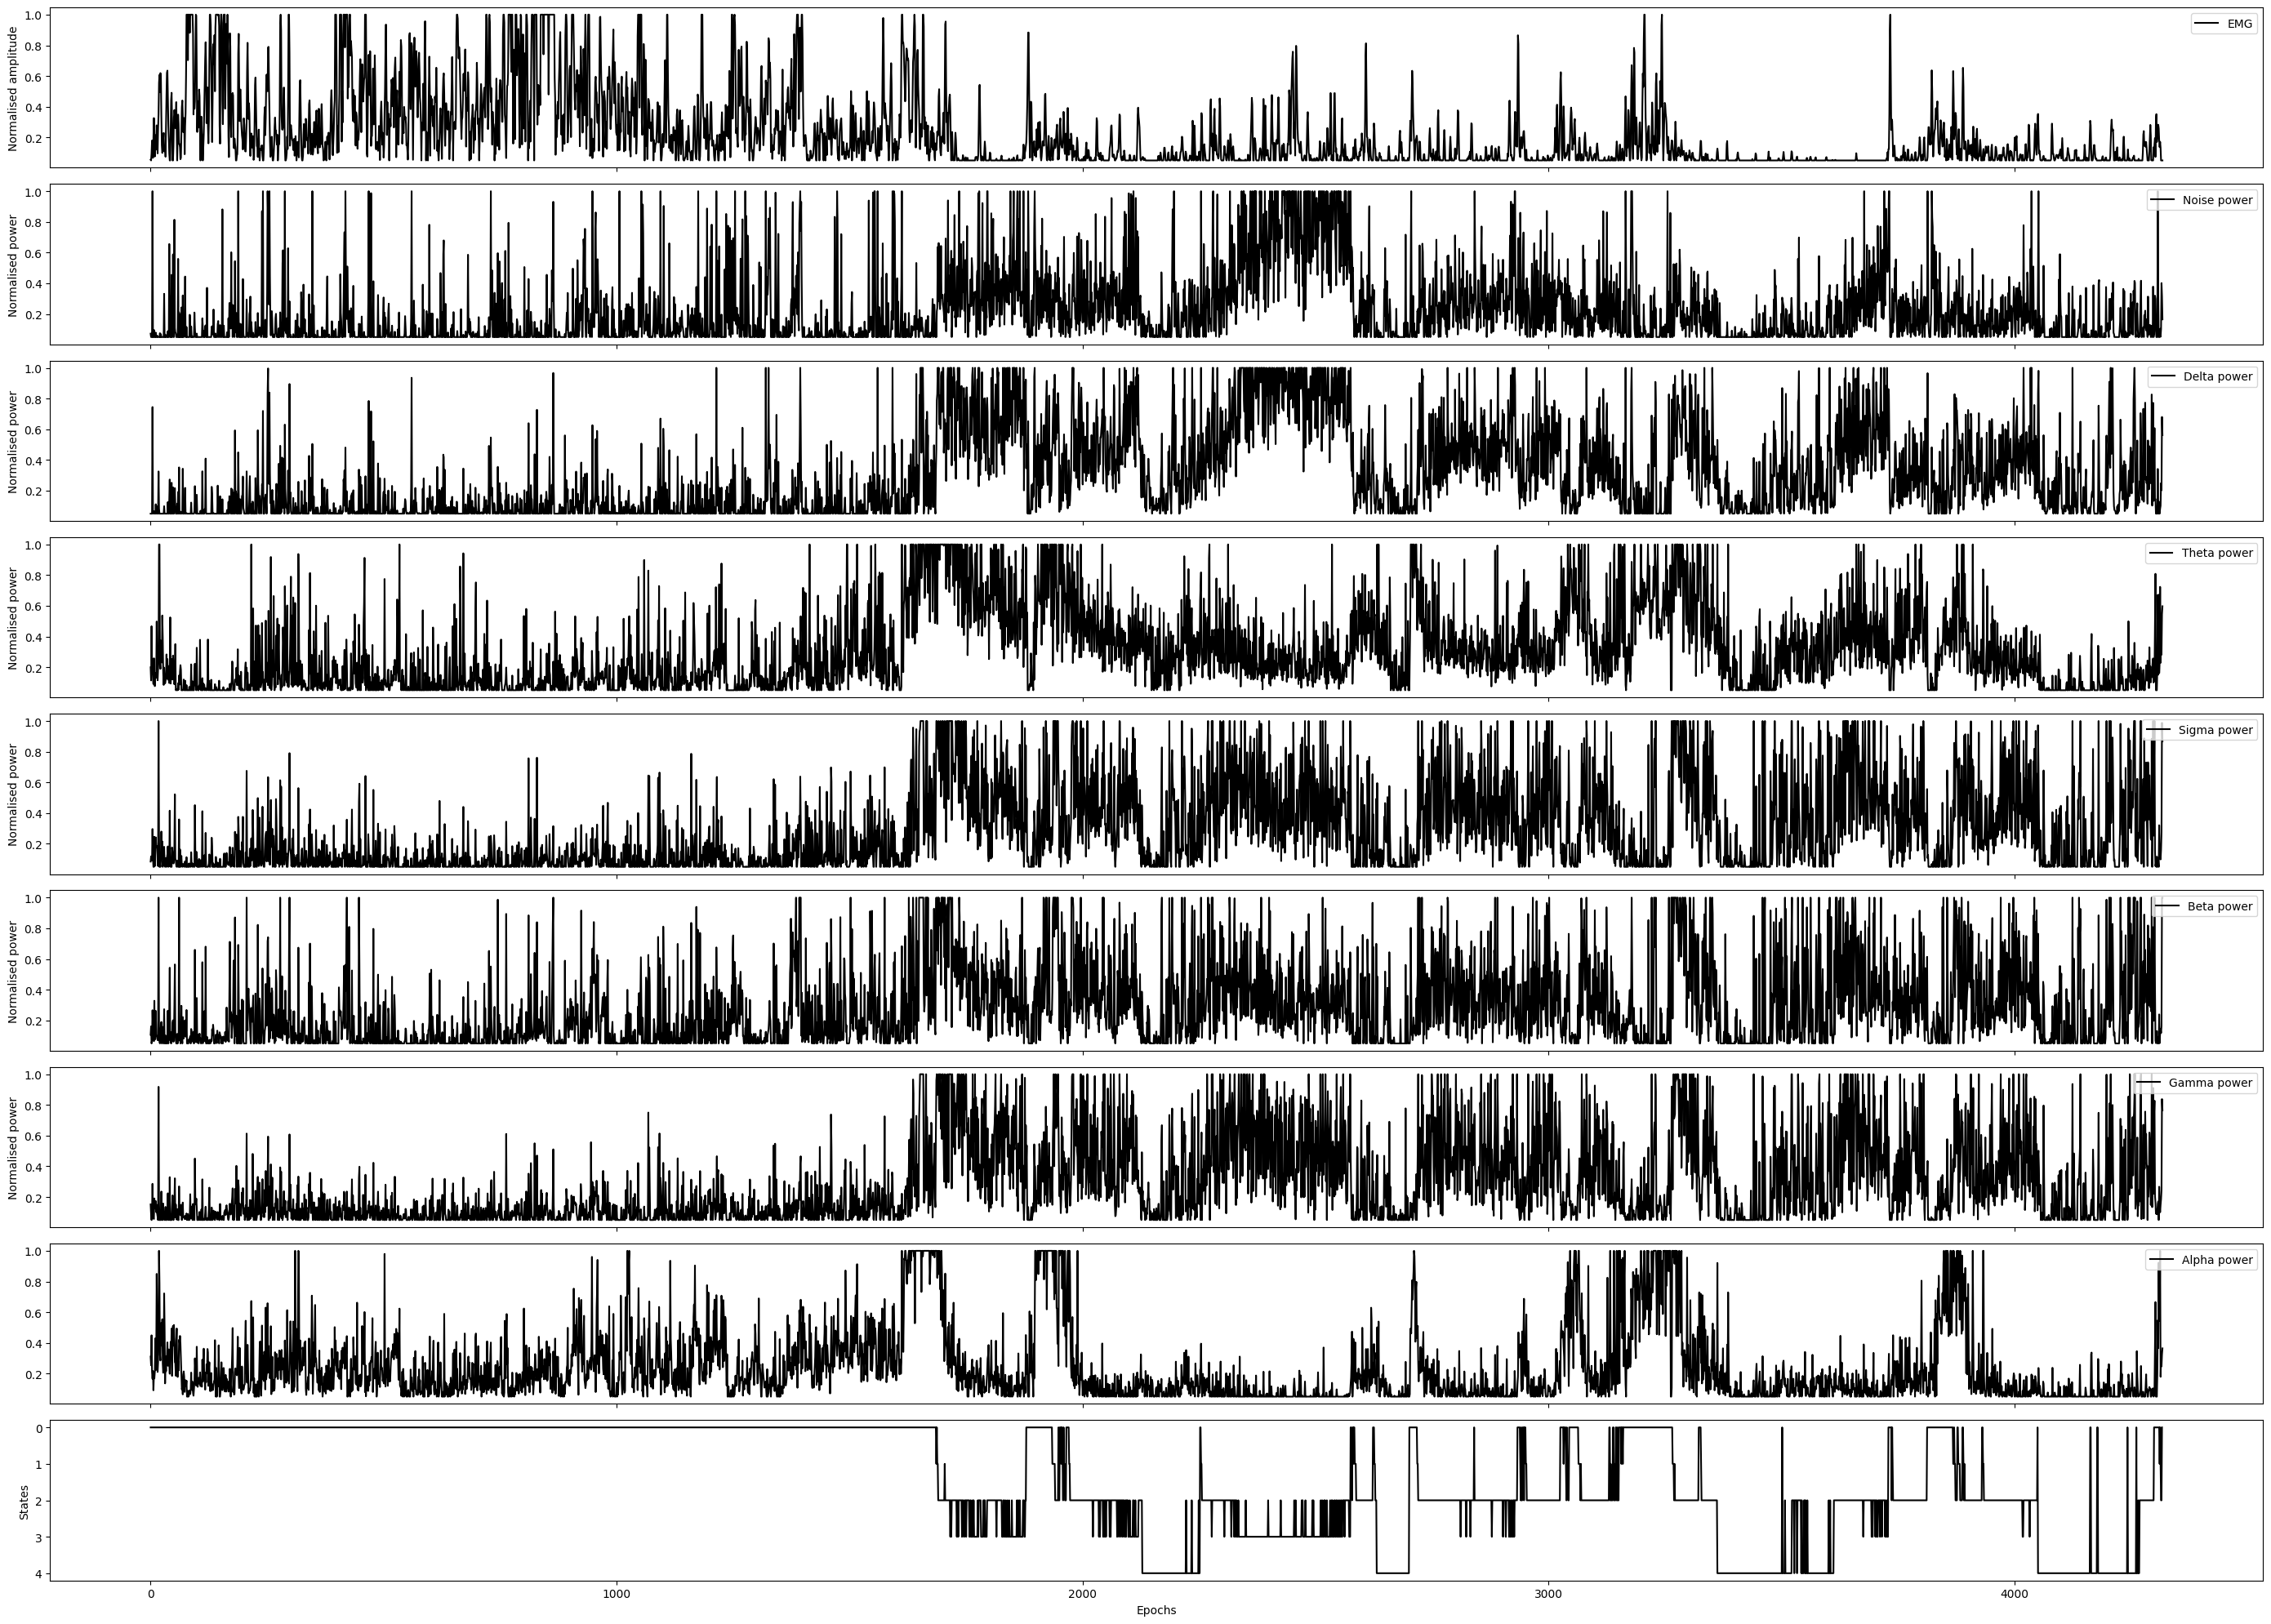

C:\Users\timmi\PycharmProjects\AutomatedSleepScoring\Human_SleepSCoring\Tim\Sleep_Scripts\feature_visualizations.py:214: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


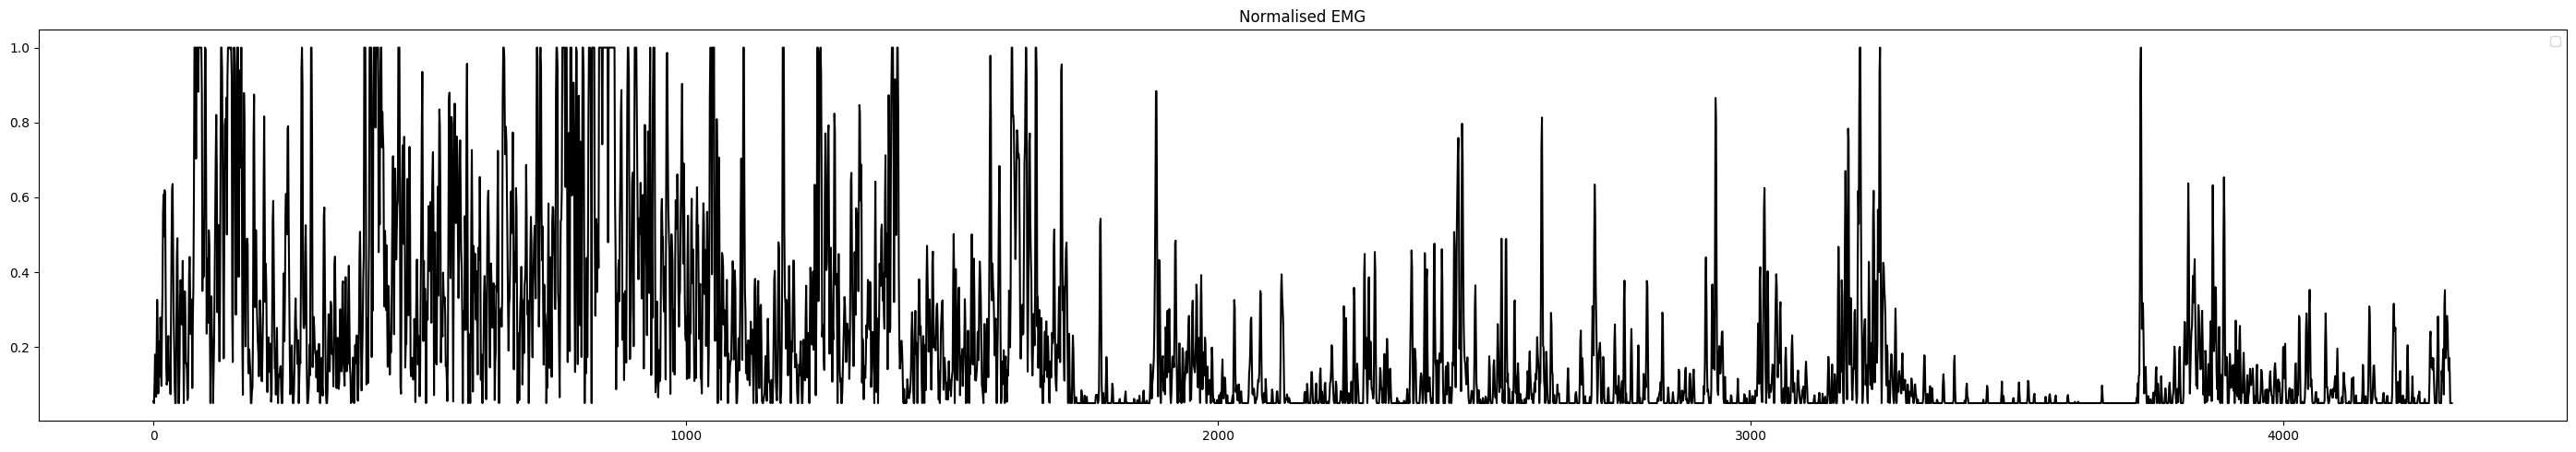

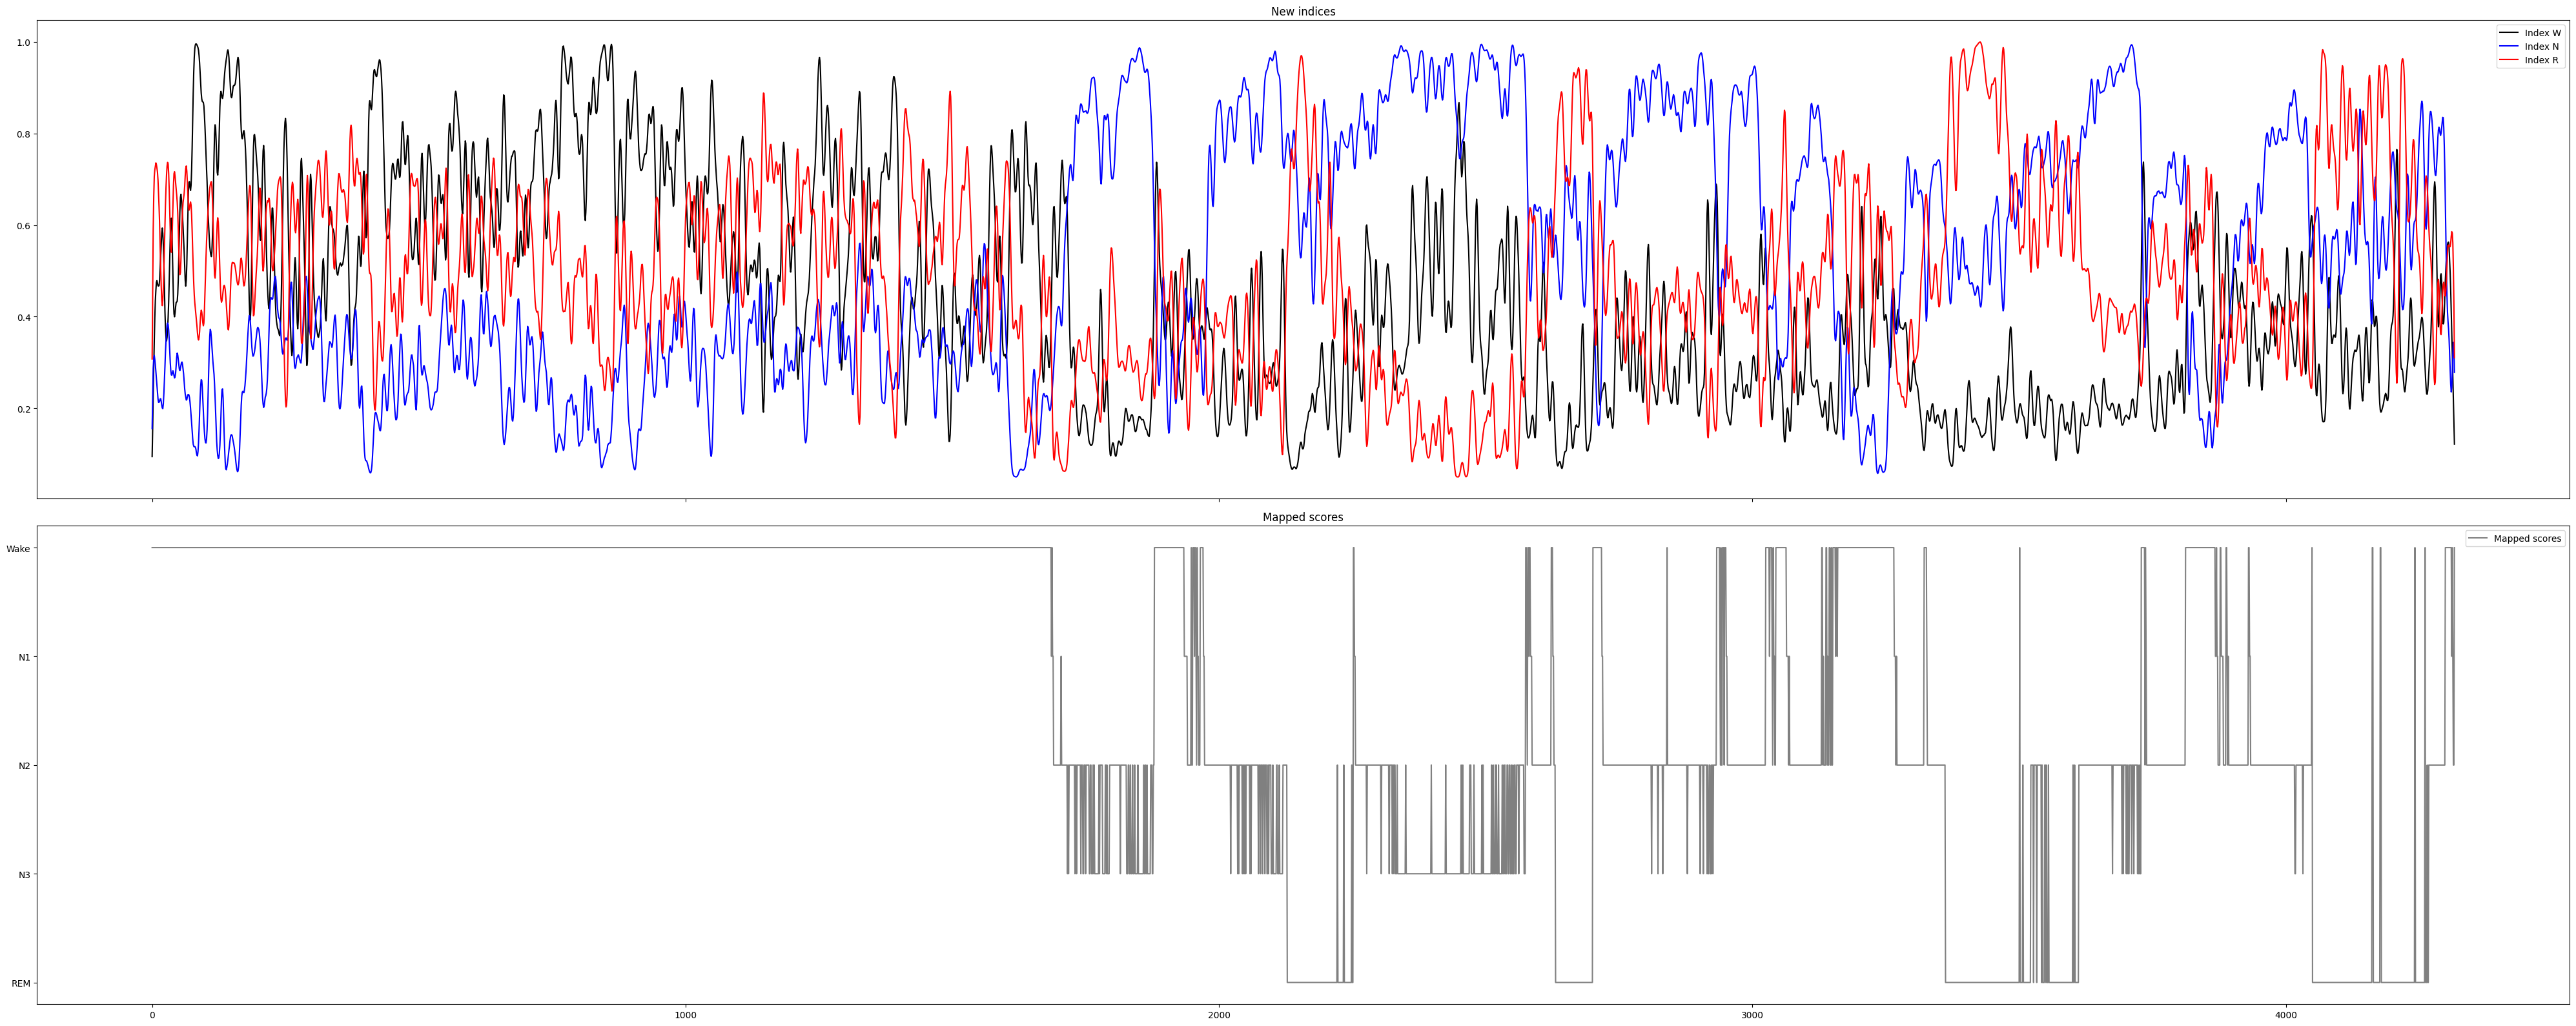

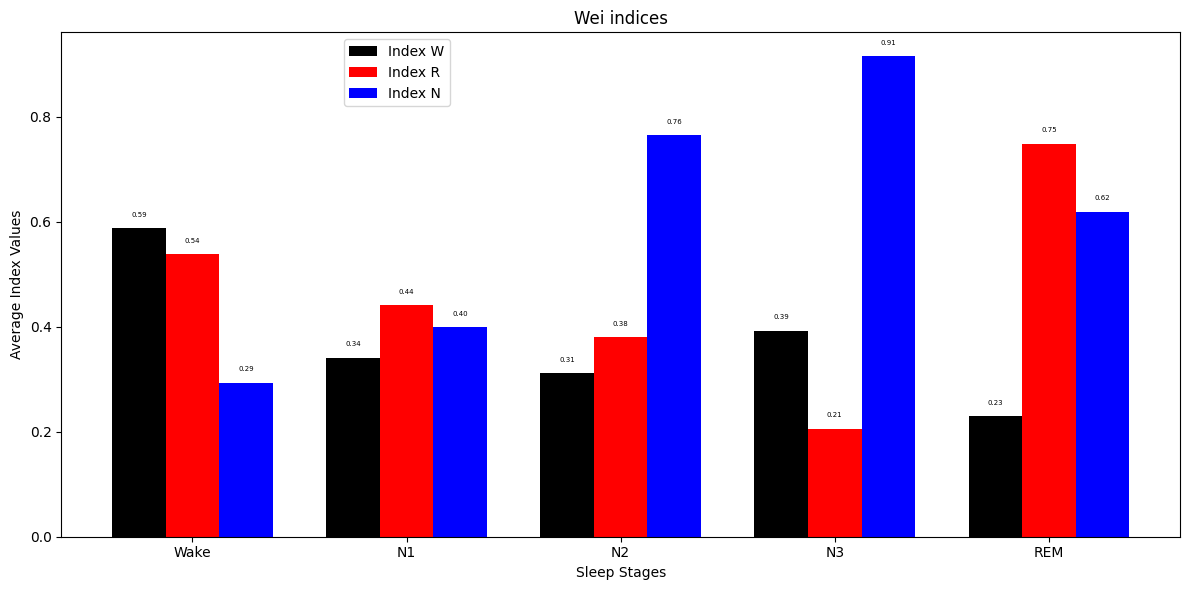

PCA data points:(4317, 3)


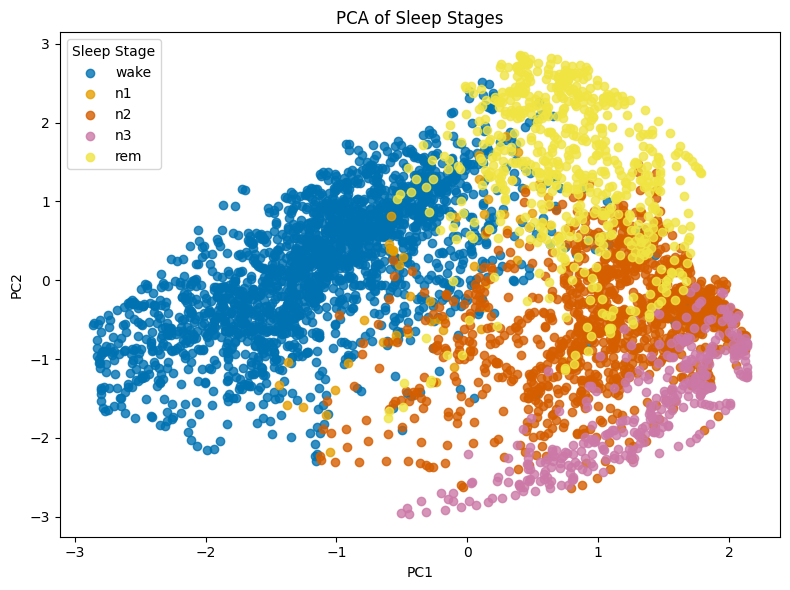

In [24]:
# Powerband plot
F.normalised_powers(EMG_norm, noise_norm, delta_norm, theta_norm, sigma_norm, beta_norm, gamma_norm, alpha_norm, hypno_epochs, sleep_scoring, output_dir)
# Normalised EMG
F.normalised_EMG(EMG_norm, output_dir)
# Raw signals
# F.raw_signals(states, raw_hpc, raw_pfc, pfc_tag, hpc_tag, output_dir)
# Indices vs a hypnogram
F.indices_vs_hypnogram(epochs, hypno_epochs, index_w, index_n, index_r, mapped_scores, output_dir)
# Index barplot
F.index_barplot(index_n, index_r, index_w, mapped_scores, output_dir)
# index PCA
F.index_pca(index_n, mapped_scores, index_r, index_w, output_dir)
# Aperiodic fit
normalized_exponents, smoothed_exponents, valid_states, aperiodic_exponents = F.aperiodic_fit(pfc_data, states, fs, raw_pfc, output_dir)

In [27]:
epoch = 10
sf = 250
fmin = 0.3
fmax = 30
f_range = (0.3, 30)
subject_fractal_data = {}
subject_slope_data = {}
subject_states = {}

subject_states[subject] = states

# get eeg data in epochs
eeg_in_epochs = raw_to_epochs(raw_pfc, sf, epoch)

# calculate fractal component
subject_fractal_data[subject] = calc_fractal_component(states, eeg_in_epochs, sf, f_range)

# calculate slopes
subject_slope_data[subject] = calc_slopes(eeg_in_epochs, sf, f_range, states)


New data shape: (4318, 2500)



KeyboardInterrupt



In [ ]:
aperiodic_by_state = defaultdict(list)
freqs_ref = {}

for subject, subject_dict in subject_fractal_data.items():
    for state, (freqs, aperiodic) in subject_dict.items():
        aperiodic_by_state[state].append(aperiodic)
        freqs_ref[state] = freqs

mean_by_state = {}
sem_by_state = {}

for state, aperiodic_list in aperiodic_by_state.items():
    arr = np.stack(aperiodic_list, axis=0)
    mean_by_state[state] = (freqs_ref[state], np.mean(arr, axis=0))
    sem_by_state[state] = (freqs_ref[state], np.std(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]))


### slopes

raw_slope_by_state = defaultdict(list)
smoothed_slope_by_state = defaultdict(list)

for subject, (_, _, raw_slopes, smoothed_slopes) in subject_slope_data.items():
    for state, slope in raw_slopes.items():
        raw_slope_by_state[state].append(slope)
    for state, slope in smoothed_slopes.items():
        smoothed_slope_by_state[state].append(slope)

mean_raw_slope_by_state = {}
sem_raw_slope_by_state = {}
mean_smoothed_slope_by_state = {}
sem_smoothed_slope_by_state = {}

for state, slope_list in raw_slope_by_state.items():
    slope_array = np.vstack(slope_list)  # shape: (n_subjects, n_epochs)
    mean_raw_slope_by_state[state] = np.mean(slope_array, axis=0)
    sem_raw_slope_by_state[state] = np.std(slope_array, axis=0) / np.sqrt(slope_array.shape[0])

for state, slope_list in smoothed_slope_by_state.items():
    slope_array = np.vstack(slope_list)
    mean_smoothed_slope_by_state[state] = np.mean(slope_array, axis=0)
    sem_smoothed_slope_by_state[state] = np.std(slope_array, axis=0) / np.sqrt(slope_array.shape[0])


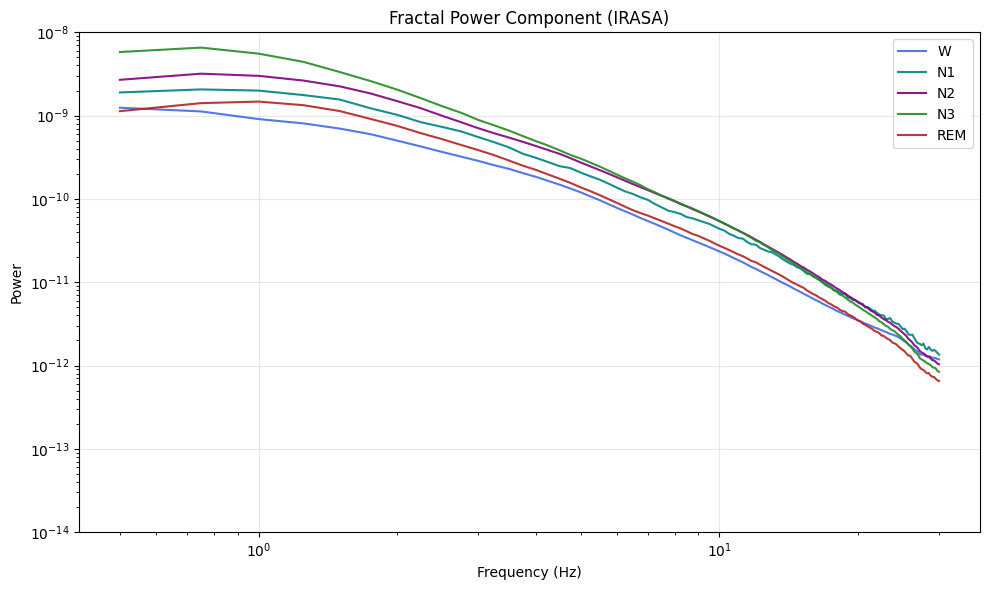

In [187]:
# Colors and labels
colors = {0: 'royalblue', 1: 'teal', 2: 'purple', 3: 'forestgreen', 4: 'firebrick'}
stage_labels = {0: 'W', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}

plt.figure(figsize=(10, 6))

for state in sorted(mean_by_state.keys()):
    freqs, mean_aperiodic = mean_by_state[state]
    _, sem_aperiodic = sem_by_state[state]

    plt.plot(
        freqs, mean_aperiodic,
        label=stage_labels.get(state, f"State {state}"),
        alpha=0.9,
        color=colors.get(state, 'gray')
    )
    
    # Shaded SEM area
    plt.fill_between(
        freqs,
        mean_aperiodic - sem_aperiodic,
        mean_aperiodic + sem_aperiodic,
        color=colors.get(state, 'gray'),
        alpha=0.15
    )

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-14, 1e-8)  # ✅ Fixed y-axis limits
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Fractal Power Component (IRASA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(f"{output_dir}/fractal_power_component.svg", format='svg')
plt.show()

In [188]:
f_range = (0.3, 30)
epoch_slopes = []
valid_states = []

for i, eeg_epoch in enumerate(eeg_in_epochs):
    freqs, psd_aperiodic, _ = compute_irasa(eeg_epoch, sf, f_range=f_range)

    # Remove invalid values
    valid = np.isfinite(psd_aperiodic) & (psd_aperiodic > 0)
    freqs = freqs[valid]
    psd_aperiodic = psd_aperiodic[valid]

    # Skip epochs with too few points
    if len(freqs) < 5:
        continue

    try:
        intercept, slope = fit_irasa(freqs, psd_aperiodic)
        epoch_slopes.append(slope)
        valid_states.append(states[i])
    except Exception:
        continue

# Convert to arrays
epoch_slopes = np.array(epoch_slopes)
valid_states = np.array(valid_states)

# Compute z-scores
raw_slopes = zscore(epoch_slopes)

# Adjust window length for savgol_filter
window_length = min(101, len(raw_slopes) // 2 * 2 + 1)  # must be odd
smoothed_slopes = savgol_filter(raw_slopes, window_length, polyorder=5, mode='interp')
smoothed_slopes = zscore(smoothed_slopes)

# Compute mean slopes per state
mean_slope_per_state = {}
smoothed_mean_slope_per_state = {}

for state in np.unique(valid_states):
    mask = valid_states == state
    mean_slope_per_state[state] = np.nanmean(raw_slopes[mask])
    smoothed_mean_slope_per_state[state] = np.nanmean(smoothed_slopes[mask])

# Extract mean slopes in sorted order
stages_sorted = sorted(mean_slope_per_state.keys())
mean_slopes = [mean_slope_per_state[s] for s in stages_sorted]
smoothed_mean_slopes = [smoothed_mean_slope_per_state[s] for s in stages_sorted]

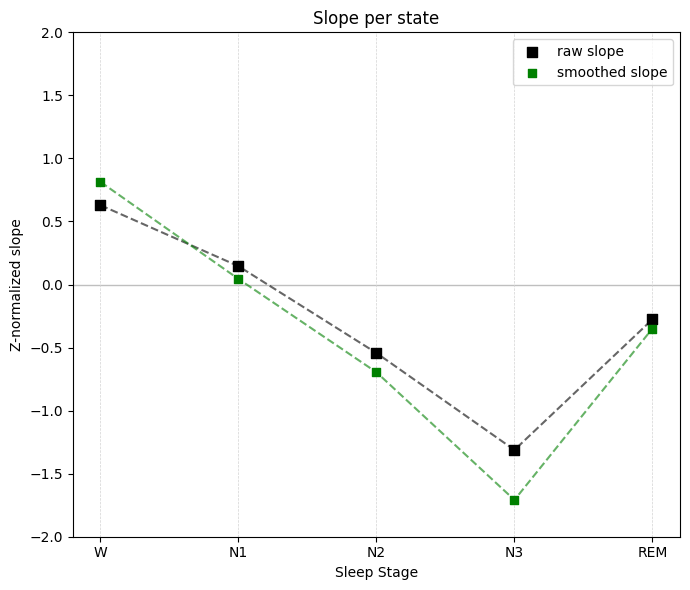

In [189]:
stages_sorted = sorted(mean_slope_per_state.keys())
# Extract means per state
mean_slopes = [np.mean(mean_raw_slope_by_state[state]) for state in stages_sorted if state in mean_raw_slope_by_state]
smoothed_mean_slopes = [np.mean(mean_smoothed_slope_by_state[state]) for state in stages_sorted if state in mean_smoothed_slope_by_state]

plt.figure(figsize=(7, 6))

# draw grid
plt.grid(axis='x', color='lightgray', linestyle='--', linewidth=0.5, zorder=0)
plt.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)

plt.scatter(stages_sorted, mean_slopes, color='black', marker='s', s=60, label='raw slope', zorder=2)
plt.scatter(stages_sorted, smoothed_mean_slopes, color='green', marker='s', s=30, label='smoothed slope', zorder=2)
plt.plot(stages_sorted, mean_slopes, color='black', linestyle='--', alpha=0.6, zorder=2)
plt.plot(stages_sorted, smoothed_mean_slopes, color='green', linestyle='--', alpha=0.6, zorder=2)

plt.xticks(stages_sorted, ['W','N1','N2','N3','REM'])
plt.ylabel('Z-normalized slope')
plt.xlabel('Sleep Stage')
plt.title('Slope per state')
plt.ylim(-2, 2)
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/slope_per_state.svg", format="svg")
plt.show()



In [190]:
peaks, _ = find_peaks(smoothed_slopes, distance=120, prominence=2)

valleys, _ = find_peaks(-smoothed_slopes, distance=120, prominence=2)

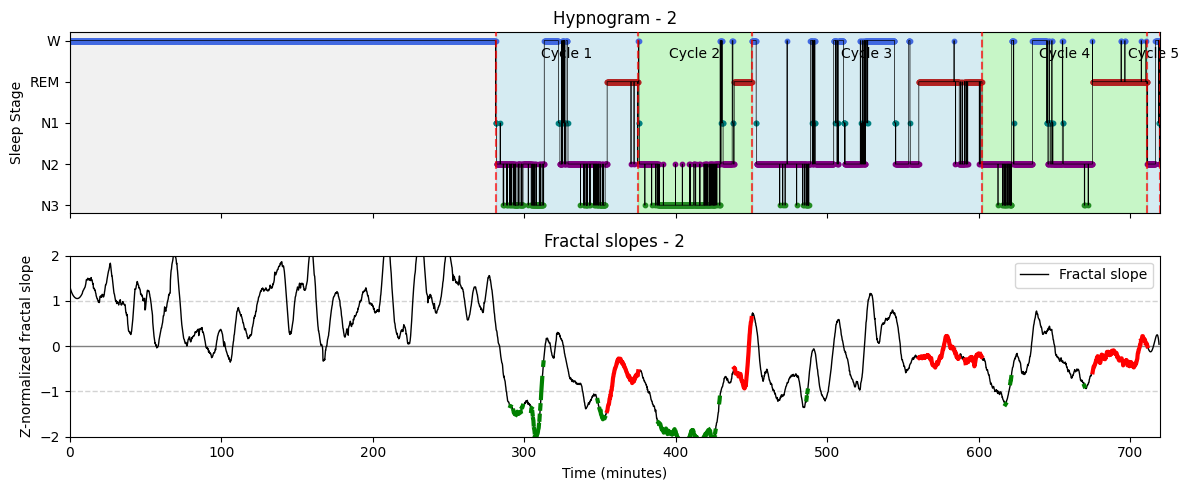

In [191]:
import pandas as pd
subj_states = states
epoch_length_sec = 10  # adjust for dataset
n_epochs = len(subj_states)
time_axis = np.arange(n_epochs) * epoch_length_sec / 60  # minutes

# define sleep stage colors
# Replace 5 with 0
# subj_states[subj_states == 5] = 0

stage_colors = {0: 'royalblue', 1: 'teal', 2: 'purple', 3: 'forestgreen', 4: 'firebrick'}
stage_labels = {0: 'W', 1:'N1', 2:'N2', 3: 'N3', 4: 'REM'}

# Parameters
REM_code = 4
min_rem_gap = 20  # ignore interruptions <= 1 epoch

# --- First non-Wake ---
non_wake_idx = np.where(subj_states != 0)[0]
first_non_wake = non_wake_idx[0] if len(non_wake_idx) > 0 else None
last_non_wake = non_wake_idx[-1] if len(non_wake_idx) > 0 else None

# --- REM clusters ---
is_rem = (subj_states == REM_code).astype(int)
diff = np.diff(np.concatenate(([0], is_rem, [0])))
run_starts = np.where(diff == 1)[0]
run_ends = np.where(diff == -1)[0] - 1

# Merge short interruptions
merged_starts = [run_starts[0]] if len(run_starts) > 0 else []
merged_ends = []
for i in range(1, len(run_starts)):
    if run_starts[i] - run_ends[i-1] - 1 <= min_rem_gap:
        continue
    else:
        merged_ends.append(run_ends[i-1])
        merged_starts.append(run_starts[i])
if len(run_ends) > 0:
    merged_ends.append(run_ends[-1])



# Desired order for y-axis
desired_order = ['W', 'REM', 'N1', 'N2', 'N3']

# Map original numeric states to their labels
stage_labels = {0:'W', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}

# Create a mapping: original numeric code -> new vertical position
new_y_map = {label: i for i, label in enumerate(desired_order)}
states_labels = np.array([stage_labels[s] for s in subj_states])
states_new_y = np.array([new_y_map[s] for s in states_labels])

# create plot layout (2 plots in 1 figure)
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,5), sharex=True)


### plot 1: colored coded hypnogram
#######################################################################
# plot plain black line hypnogram
# --- Create list of vertical line positions ---
line_positions = [first_non_wake] + merged_ends if first_non_wake is not None else merged_ends
# Add the last non-wake if it isn’t already in the list
if last_non_wake is not None and last_non_wake not in line_positions:
    line_positions.append(last_non_wake)
line_positions = [0] + line_positions + [len(subj_states)-1]  # include start and end
line_times = time_axis[line_positions]

# --- Plot hypnogram ---
ax1.step(time_axis, states_new_y, where='post', color='black', linewidth=0.5, zorder=2)

# Shade regions between lines (alternating) and outside
colors = ['lightgreen', 'lightblue']
for i in range(1, len(line_times)-2):
    start = line_times[i]
    end = line_times[i+1]
    ax1.axvspan(line_times[i], line_times[i+1], color=colors[i % 2], alpha=0.5, zorder=1)
    # Add cycle label at the center of the shaded region
    center = (start + end) / 2
    ax1.text(center, 0.5, f'Cycle {i}',
             ha='center', va='bottom', fontsize=10, color='black')

# Shade outside areas
ax1.axvspan(time_axis[0], line_times[1], color='lightgray', alpha=0.3, zorder=0)     # before first non-Wake/cluster
ax1.axvspan(line_times[-2], time_axis[-1], color='lightgray', alpha=0.3, zorder=0)   # after last cluster

# Draw vertical lines
for t in line_times[1:-1]:  # avoid start and end
    ax1.axvline(t, color='red', linestyle='--', alpha=0.7, zorder=3)

# plot dots colored based on state
for s_num in np.unique(subj_states):
    ids = np.where(subj_states == s_num)[0]
    ax1.scatter(time_axis[ids], states_new_y[ids],
                color=stage_colors[s_num], label=stage_labels[s_num], s=10)

# additional settings
ax1.set_yticks(range(len(desired_order)))
ax1.set_yticklabels(desired_order)
ax1.set_ylabel('Sleep Stage')
ax1.invert_yaxis()
ax1.set_xlim(time_axis[0], time_axis[-1])
ax1.set_title(f'Hypnogram - {subject}')

difference = len(time_axis) - len(smoothed_slopes)
### plot 2: smoothed fractal slope
########################################################################
ax2.plot(time_axis[:-difference], smoothed_slopes, color='black', label='Fractal slope', linewidth=1)
# color lines based on sleep state
# Define colors for N3 and REM
stage_colors = {3: 'green', 4: 'red'}

# Loop over stages to color the segments
for stage, color in stage_colors.items():
    # Find contiguous segments of this stage
    mask = (subj_states == stage)
    if not np.any(mask):
        continue  # skip if stage not present
    
    # Split into contiguous segments
    segments = np.split(time_axis, np.where(np.diff(mask.astype(int)) != 0)[0]+1)
    slope_segments = np.split(smoothed_slopes, np.where(np.diff(mask.astype(int)) != 0)[0]+1)
    
    for t_seg, s_seg, m_seg in zip(segments, slope_segments, np.split(mask, np.where(np.diff(mask.astype(int)) != 0)[0]+1)):
        if np.any(m_seg):  # only plot segments where mask is True
            ax2.plot(t_seg[m_seg], s_seg[m_seg], color=color, linewidth=3)


# Solid line at 0
ax2.axhline(0, color='gray', linewidth=1, zorder=1)

# Dashed lines at +1 and -1
ax2.axhline(1, color='lightgray', linestyle='--', linewidth=1, zorder=1)
ax2.axhline(-1, color='lightgray', linestyle='--', linewidth=1, zorder=1)

# additional settings
ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('Z-normalized fractal slope')
ax2.set_ylim(-2, 2)
ax2.set_xlim(time_axis[0], time_axis[-1])
ax2.set_title(f'Fractal slopes - {subject}')
ax2.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/fractalslope_vs_hypnogram.svg", format='svg')
plt.show()

                                                                                                  
                                   FOOOF - POWER SPECTRUM MODEL                                   
                                                                                                  
                        The model was run on the frequency range 1 - 50 Hz                        
                                 Frequency Resolution is 0.24 Hz                                  
                                                                                                  
                            Aperiodic Parameters (offset, exponent):                              
                                         -6.9512, 3.8237                                          
                                                                                                  
                                       3 peaks were found:                                        
          

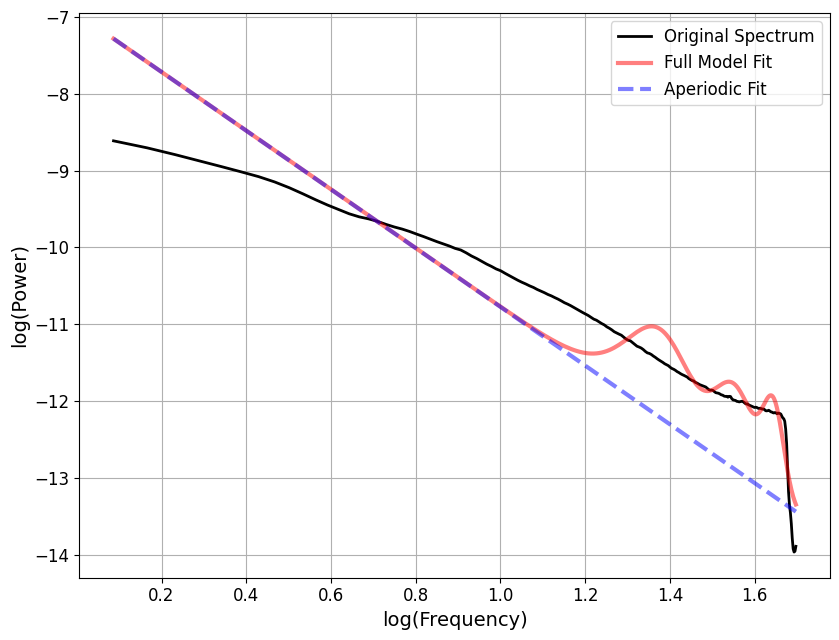

In [192]:

freqs, psd = welch(raw_pfc, fs=250, nperseg=1024)

# Initialize and fit FOOOF model
fm = FOOOF(peak_width_limits=[2, 8], aperiodic_mode='fixed')

# Generate the report (this creates a matplotlib figure)
fm.report(freqs, psd, [1, 50], plt_log=True)

# Save the report plot to a file (e.g., PNG or PDF)
plt.savefig(f"{output_dir}/fooof_report.png", dpi=300, bbox_inches='tight')
plt.show()

In [193]:
colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick']
labels = ['W', 'N1', 'N2', 'N3', 'REM']

df = pd.DataFrame({'state': valid_states, 'aperiodic': normalized_exponents})
summary = df.groupby('state')['aperiodic'].agg(['mean', 'sem']).reset_index()
print(summary)
plt.figure(figsize=(7, 5))
plt.bar(summary['state'], summary['mean'], yerr=summary['sem'],
        capsize=5, color=[colors[int(s)] for s in summary['state']], edgecolor='black', zorder=2, alpha=0.6)
plt.xticks([0, 1, 2, 3, 4], ['W','N1','N2','N3','REM'])
plt.ylim(-1.1, 1.1)
plt.xlabel('Sleep State')
plt.ylabel('Normalized mean aperiodic fit')
plt.title('Aperiodic per Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/Aperiodic_fit_bar.svg", format='svg')
plt.show()

ValueError: All arrays must be of the same length

In [196]:
# df = pd.DataFrame({'state': valid_states, 'aperiodic': normalized_exponents})
# summary = df.groupby('state')['aperiodic'].agg(['mean', 'sem']).reset_index()
print(len(valid_states))
print(len(normalized_exponents))
# print(len(summary['sem']))

4314
4144
